In [52]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect
import pandas as pd
import conductivity as cd

# Conductivity of Simple Ionic Mixtures

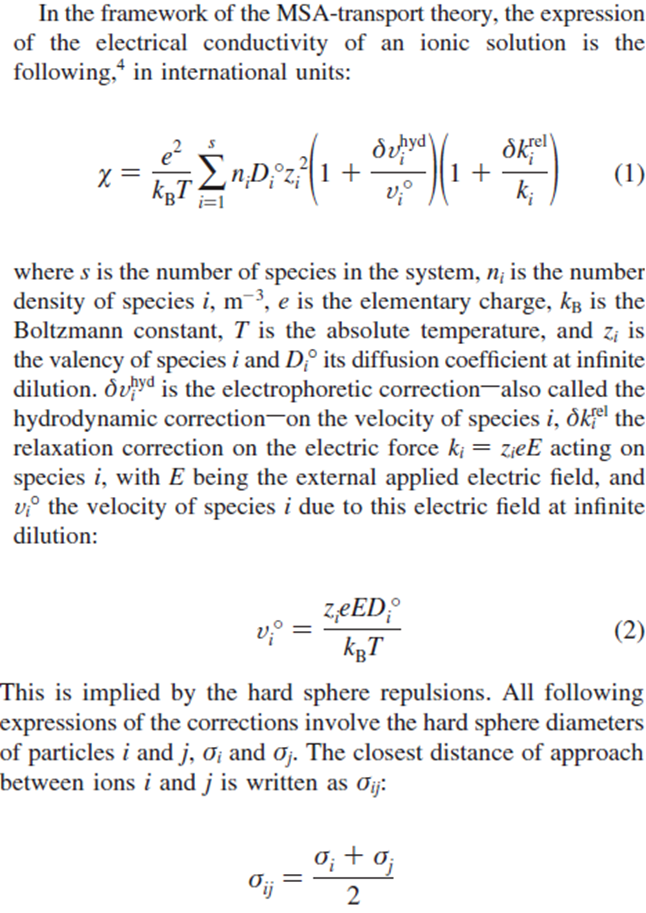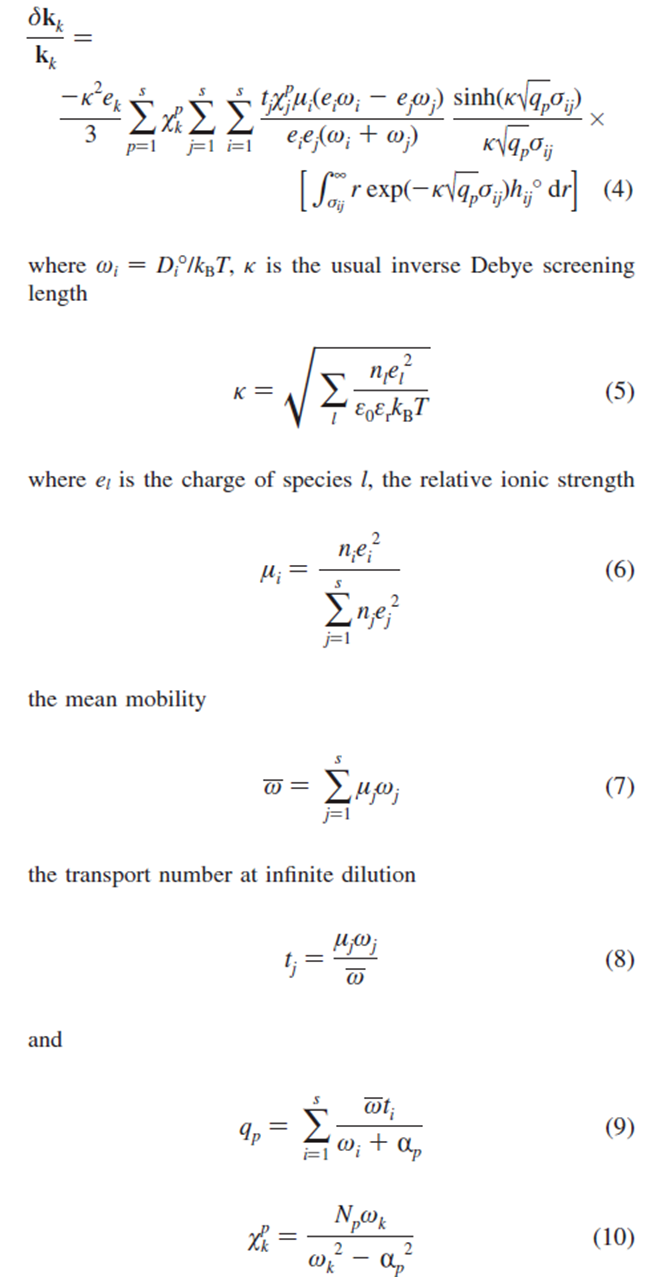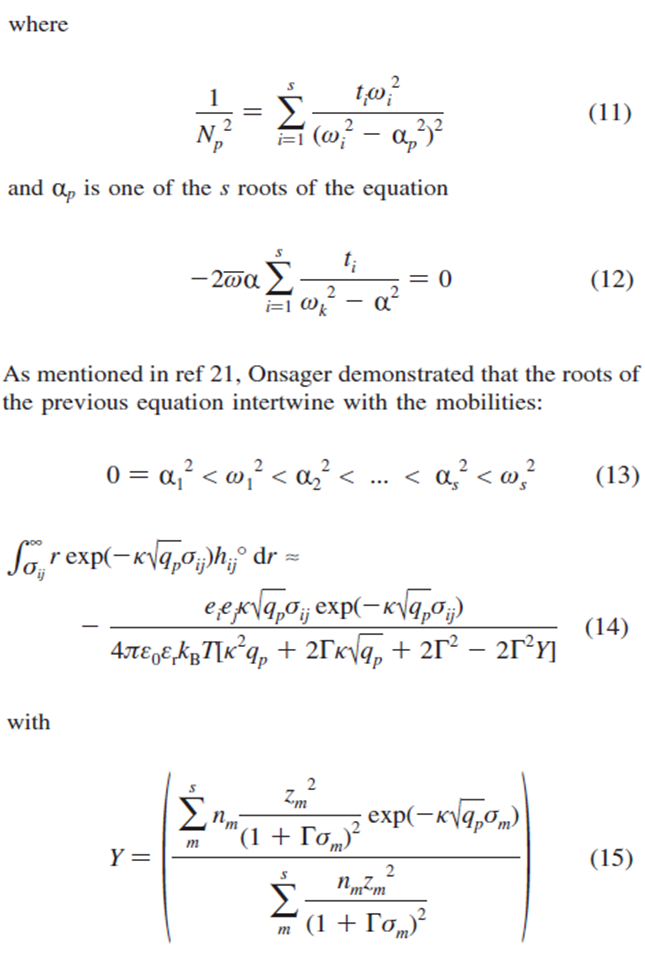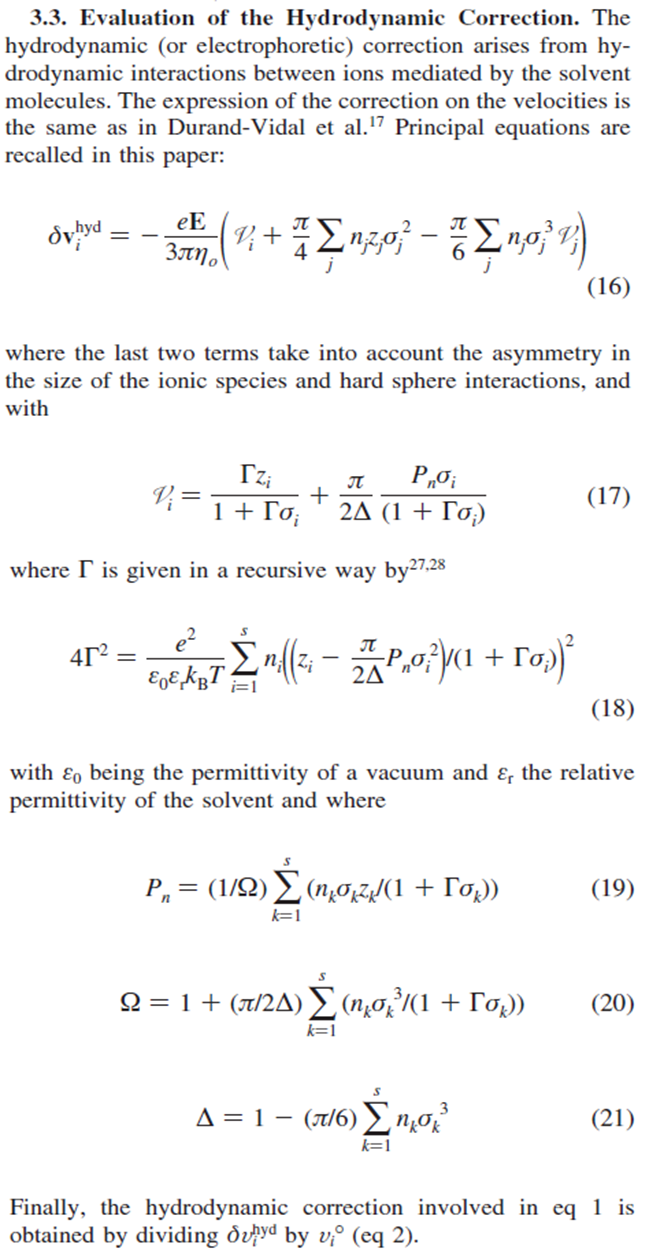

# Double Salts Prediction

## Data for Double Salts

In [53]:
# loading NaCl and CaCl2 experiment data
data = pd.read_csv("./Data/NaCl_CaCl2_rearranged.csv")
NaCl_conc = data["NaCl conc"]
NaCl_conc12 = data["NaCl conc2"]
NaCl_conc13 = data["NaCl conc3"]
CaCl2_conc = data["CaCl2 conc"]
CaCl2_conc12 = data["CaCl2 conc2"]
CaCl2_conc13 = data["CaCl2 conc3"]
cond_exp = data["Cal bulk cond"]
cond_exp12 = data["Cal bulk cond2"]
cond_exp13 = data["Cal bulk cond3"]
# cond_exp = data["Bulk cond"]
# cond_exp12 = data["Bulk cond2"]
# cond_exp13 = data["Bulk cond3"]


# number of data points
ndata = len(cond_exp)

In [54]:
# loading CaCl2 and LaCl3 experiment data
data2 = pd.read_csv("./Data/CaCl2_LaCl3_rearranged.csv")
LaCl3_conc = data2["LaCl3 conc"]
LaCl3_conc12 = data2["LaCl3 conc2"]
LaCl3_conc13 = data2["LaCl3 conc3"]
CaCl2_conc2 = data2["CaCl2 conc"]
CaCl2_conc22 = data2["CaCl2 conc2"]
CaCl2_conc23 = data2["CaCl2 conc3"]
cond_exp2 = data2["Cal bulk cond"]
cond_exp22 = data2["Cal bulk cond2"]
cond_exp23 = data2["Cal bulk cond3"]
# cond_exp2 = data2["Bulk cond"]

# number of data points
ndata2 = len(cond_exp2)

In [55]:
# loading NaCl and LaCl3 experiment data
data4 = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc2 = data4["NaCl conc"]
NaCl_conc22 = data4["NaCl conc2"]
NaCl_conc23 = data4["NaCl conc3"]
LaCl3_conc2 = data4["LaCl3 conc"]
LaCl3_conc22 = data4["LaCl3 conc2"]
LaCl3_conc23 = data4["LaCl3 conc3"]
cond_exp3 = data4["Cal bulk cond"]
cond_exp32 = data4["Cal bulk cond2"]
cond_exp33 = data4["Cal bulk cond3"]
# cond_exp3 = data4["Bulk cond"]

# number of data points
ndata4 = len(cond_exp3)

## Constants

In [56]:
# temperature
T = 298.15

# diffusion coefficients at infinite dilution
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3

# measuring voltage and probe distance
voltage = 25 * 10**(-3)
distance = 9 * 10**(-6)

# hard sphere diameters
sigma_Cl = 200 * 10**(-12)
sigma_Ca = 200 * 10**(-12)
sigma_La = 206.4 * 10**(-12)
sigma_Na = 204 * 10**(-12)

# solvent viscosity
eta = 0.89 * 10**(-3)

# electric field
E_field = voltage/distance

# relative permittivity
epsilon = 78.4

## MSA Transport Model

### NaCl and CaCl2

In [57]:
# constants
diffusion_coeff = [Diff_Ca, Diff_Na, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Ca, z_Na, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Ca, sigma_Na, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con =cd.msa_transport(valency, diameter, diffusion_coeff, T, voltage, distance, eta, epsilon, CaCl2_conc, NaCl_conc)
all_cond_calc_con12 = cd.msa_transport(valency, diameter, diffusion_coeff, T, voltage, distance, eta, epsilon, CaCl2_conc12, NaCl_conc12)
all_cond_calc_con13 = cd.msa_transport(valency, diameter, diffusion_coeff, T, voltage, distance, eta, epsilon, CaCl2_conc13, NaCl_conc13)

Relaxation correction: [-3.38783398e-11 -1.22664106e-11 -2.66743634e-11]
Hydrodynamic correction: [-0.35677704 -0.21134431 -0.139037  ]
omega_bar: 321740280365.1725
Alpha: [0.0, 275118320719.31915, 381397438525.5137]
Mew: [0.5   0.125 0.375]
Transport number: [0.29892433 0.12587281 0.57520287]
Omega: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.52379051 -0.94333929 -0.36537891]
 [ 0.90467922  2.09978239 -1.64833163]
 [ 0.59391835  0.55785826  1.03661575]]
Relaxation correction: [-3.05909928e-11 -1.08726281e-11 -2.66473199e-11]
Hydrodynamic correction: [-0.33828472 -0.20040888 -0.13184011]
omega_bar: 309310608411.8851
Alpha: [0.0, 291839212055.8278, 374919546231.9499]
Mew: [0.57142857 0.07142857 0.35714286]
Transport number: [0.35535614 0.07481772 0.56982614]
Omega: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.46130484 -0.71446761 -0.41012496]
 [ 0.86758128  2.92813261 -2.00976597]
 [ 0.5695637   0.55752166  1.05815313]]
Relaxation correction: [-2.95792476e-11 -1

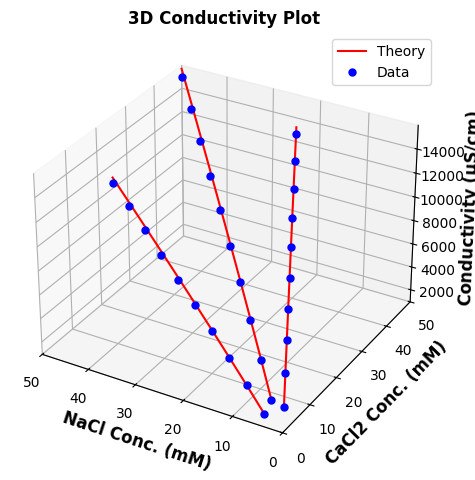

In [58]:
# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, all_cond_calc_con, color="red", label="Theory")
ax.plot3D(NaCl_conc12, CaCl2_conc12, all_cond_calc_con12, color="red")
ax.plot3D(NaCl_conc13, CaCl2_conc13, all_cond_calc_con13, color="red")
ax.plot3D(NaCl_conc, CaCl2_conc, cond_exp, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc12, CaCl2_conc12, cond_exp12, "b.", markersize=10)
ax.plot3D(NaCl_conc13, CaCl2_conc13, cond_exp13, "b.", markersize=10)
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaCl2 Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
# plt.savefig("msc_model_na_ca.png")
plt.show()

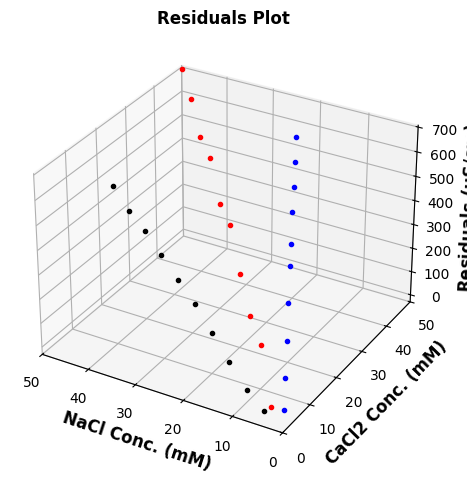

In [59]:
# residuals for NaCl and CaCl2
e = [all_cond_calc_con[i] - cond_exp[i] for i in range(ndata)]
e12 = [all_cond_calc_con12[i] - cond_exp12[i] for i in range(ndata)]
e13 = [all_cond_calc_con13[i] - cond_exp13[i] for i in range(ndata)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, e, "r.")
ax.plot3D(NaCl_conc12, CaCl2_conc12, e12, "b.")
ax.plot3D(NaCl_conc13, CaCl2_conc13, e13, ".", color="black")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaCl2 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("residuals_msc_model_na_ca.png")
plt.show()

4.12767943992488
3.509044236271218
2.9729809602498016


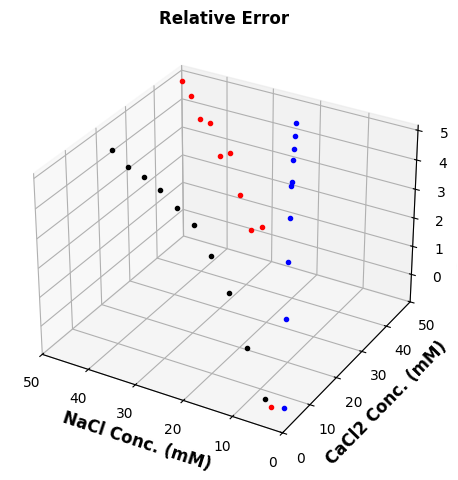

In [60]:
# residuals percent or fraction
residuals_percent = [100*e[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12 = [100*e12[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13 = [100*e13[i]/cond_exp13[i] for i in range(ndata)]

# absolute value of relative error
residuals_percent_abs = [np.abs(residuals_percent[i]) for i in range(ndata)]
residuals_percent12_abs = [np.abs(residuals_percent12[i]) for i in range(ndata)]
residuals_percent13_abs = [np.abs(residuals_percent13[i]) for i in range(ndata)]
print(np.mean(residuals_percent_abs))
print(np.mean(residuals_percent12_abs))
print(np.mean(residuals_percent13_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, residuals_percent, "r.")
ax.plot3D(NaCl_conc12, CaCl2_conc12, residuals_percent12, "b.")
ax.plot3D(NaCl_conc13, CaCl2_conc13, residuals_percent13, ".", color="black")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaCl2 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("proportion_msc_model_na_ca.png")
plt.show()

### CaCl2 and LaCl3

In [61]:
# constants
diffusion_coeff_2 = [Diff_La, Diff_Ca, Diff_Cl] # diffusion coefficients of La, Ca, and Cl, respectively
valency_2 = [z_La, z_Ca, z_Cl] # valencies of La, Ca, and Cl, respectively
diameter_2 = [sigma_La, sigma_Ca, sigma_Cl] # effective ionic diameters of La, Ca, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con2 = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, T, voltage, distance, eta, epsilon, LaCl3_conc, CaCl2_conc2)
all_cond_calc_con22 = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, T, voltage, distance, eta, epsilon, LaCl3_conc12, CaCl2_conc22)
all_cond_calc_con23 = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, T, voltage, distance, eta, epsilon, LaCl3_conc13, CaCl2_conc23)

Relaxation correction: [-4.64938016e-11 -1.95996500e-11 -3.57361409e-11]
Hydrodynamic correction: [-0.43566806 -0.34171625 -0.13314629]
omega_bar: 254998618549.4704
Alpha: [0.0, 177514916972.00076, 357552337024.4243]
Mew: [0.5        0.22222222 0.27777778]
Transport number: [0.2947775  0.16762792 0.53759458]
Omega: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
ksi: [[ 1.49560678 -0.98603166 -0.42812508]
 [ 1.1689149   2.0485397  -0.63459947]
 [ 0.45560069  0.13602522  1.27830472]]
Relaxation correction: [-5.61884074e-11 -2.48737515e-11 -3.82943183e-11]
Hydrodynamic correction: [-0.48805241 -0.38296466 -0.14922459]
omega_bar: 264433392030.6449
Alpha: [0.0, 170446449841.47757, 357402378151.1003]
Mew: [0.375      0.33333333 0.29166667]
Transport number: [0.21319506 0.24247063 0.54433432]
Omega: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
ksi: [[ 1.55828361 -1.44328908 -0.42333097]
 [ 1.21790095  1.49901735 -0.62759471]
 [ 0.47469368  0.14249471  1.26153378]]
Relaxation correction: [-4

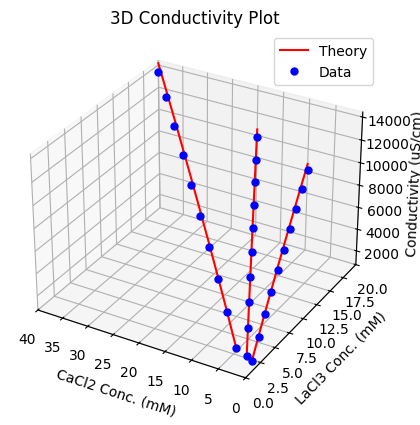

In [62]:
# making plot comparison of calculated and experimental conductivity of CaCl2 and LaCl3
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, all_cond_calc_con2, color="red", label="Theory")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, all_cond_calc_con22, color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, all_cond_calc_con23, color="red")
ax.plot3D(CaCl2_conc2, LaCl3_conc, cond_exp2, "b.", markersize=10, label="Data")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, cond_exp22, "b.", markersize=10)
ax.plot3D(CaCl2_conc23, LaCl3_conc13, cond_exp23, "b.", markersize=10)
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.set_title('3D Conductivity Plot')
ax.set_zlabel("Conductivity (uS/cm)")
ax.set_xlabel("CaCl2 Conc. (mM)")
ax.set_ylabel("LaCl3 Conc. (mM)")
ax.legend()
plt.show()

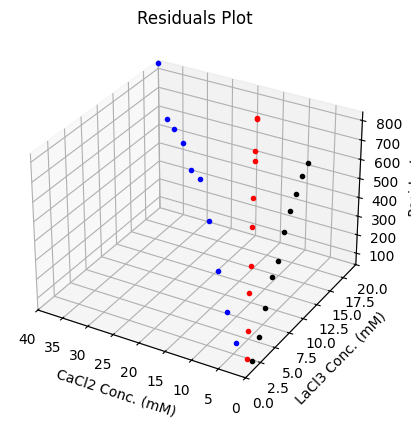

In [63]:
# residuals for CaCl2 and LaCl3
e2 = [all_cond_calc_con2[i] - cond_exp2[i] for i in range(ndata2)]
e22 = [all_cond_calc_con22[i] - cond_exp22[i] for i in range(ndata2)]
e23 = [all_cond_calc_con23[i] - cond_exp23[i] for i in range(ndata2)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, e2, "r.")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, e22, "b.")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, e23, ".", color="black")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.set_title("Residuals Plot")
ax.set_zlabel("Residuals")
ax.set_xlabel("CaCl2 Conc. (mM)")
ax.set_ylabel("LaCl3 Conc. (mM)")
plt.show()

7.209292500040531
6.626651147504495
6.751936370872227


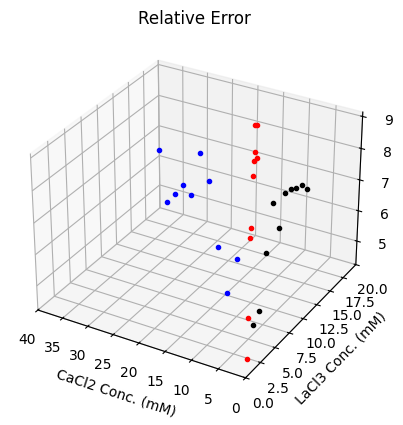

In [64]:
# residuals percent or fraction
residuals_percent2 = [100*e2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22 = [100*e22[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23 = [100*e23[i]/cond_exp23[i] for i in range(ndata2)]

# absolute value of relative error
residuals_percent2_abs = [np.abs(residuals_percent2[i]) for i in range(ndata2)]
residuals_percent22_abs = [np.abs(residuals_percent22[i]) for i in range(ndata2)]
residuals_percent23_abs = [np.abs(residuals_percent23[i]) for i in range(ndata2)]
print(np.mean(residuals_percent2_abs))
print(np.mean(residuals_percent22_abs))
print(np.mean(residuals_percent23_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, residuals_percent2, "r.")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, residuals_percent22, "b.")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, residuals_percent23, ".", color="black")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.set_title("Relative Error")
ax.set_zlabel("Residuals (%)")
ax.set_xlabel("CaCl2 Conc. (mM)")
ax.set_ylabel("LaCl3 Conc. (mM)")
plt.show()

### NaCl and LaCl3

In [65]:
# constants
diffusion_coeff_3 = [Diff_La, Diff_Na, Diff_Cl] # diffusion coefficients of La, Na, and Cl, respectively
valency_3 = [z_La, z_Na, z_Cl] # valencies of La, Na, and Cl, respectively
diameter_3 = [sigma_La, sigma_Na, sigma_Cl] # effective ionic diameters of La, Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con3 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, voltage, distance, eta, epsilon, LaCl3_conc2, NaCl_conc2)
all_cond_calc_con32 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, voltage, distance, eta, epsilon, LaCl3_conc22, NaCl_conc22)
all_cond_calc_con33 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, voltage, distance, eta, epsilon, LaCl3_conc23, NaCl_conc23)

Relaxation correction: [-4.09179118e-11 -5.12816897e-12 -3.19704761e-11]
Hydrodynamic correction: [-0.39350334 -0.18284588 -0.12020655]
omega_bar: 260788916222.98755
Alpha: [0.0, 280185123994.9613, 378474712351.47736]
Mew: [0.64285714 0.07142857 0.28571429]
Transport number: [0.37058471 0.08873811 0.54067718]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50778913 -0.58944861 -0.27849707]
 [ 0.69964128  2.68345218 -1.89174574]
 [ 0.45931175  0.65539633  1.09955484]]
Relaxation correction: [-5.32158645e-11 -8.41316360e-12 -3.08145141e-11]
Hydrodynamic correction: [-0.43555978 -0.20242105 -0.13308951]
omega_bar: 293668709070.8091
Alpha: [0.0, 242876329097.13528, 388092787538.26306]
Mew: [0.5        0.16666667 0.33333333]
Transport number: [0.25596141 0.18387319 0.5601654 ]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.69629658 -0.98749428 -0.23296339]
 [ 0.78711213  1.6842391  -1.40795025]
 [ 0.51673602  0.63912188  1.0534202 ]]
Relaxation correction: [

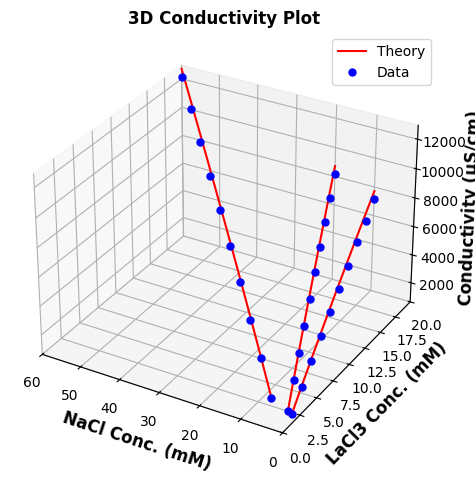

In [66]:
# making plot comparison of calculated and experimental conductivity of NaCl and LaCl3
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, all_cond_calc_con3, color="red", label="Theory")
ax.plot3D(NaCl_conc22, LaCl3_conc22, all_cond_calc_con32, color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, all_cond_calc_con33, color="red")
ax.plot3D(NaCl_conc2, LaCl3_conc2, cond_exp3, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc22, LaCl3_conc22, cond_exp32, "b.", markersize=10)
ax.plot3D(NaCl_conc23, LaCl3_conc23, cond_exp33, "b.", markersize=10)
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaCl3 Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
# plt.savefig("msc_model_na_la.png")
plt.show()

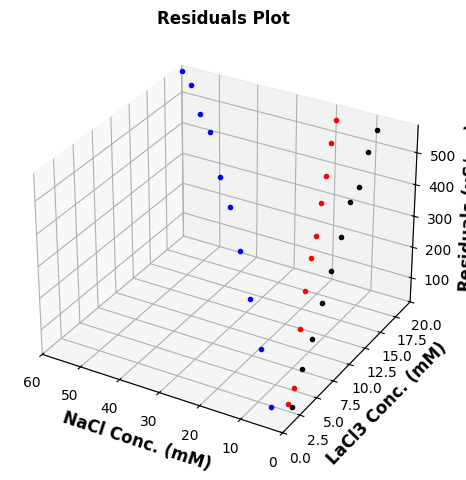

In [67]:
# residuals for NaCl and LaCl3
e3 = [all_cond_calc_con3[i] - cond_exp3[i] for i in range(ndata4)]
e32 = [all_cond_calc_con32[i] - cond_exp32[i] for i in range(ndata4)]
e33 = [all_cond_calc_con33[i] - cond_exp33[i] for i in range(ndata4)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, e3, "r.")
ax.plot3D(NaCl_conc22, LaCl3_conc22, e32, "b.")
ax.plot3D(NaCl_conc23, LaCl3_conc23, e33, ".", color="black")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaCl3 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("residuals_msc_model_na_la.png")
plt.show()

6.383652904182338
5.337358758229401
7.5051148489839346


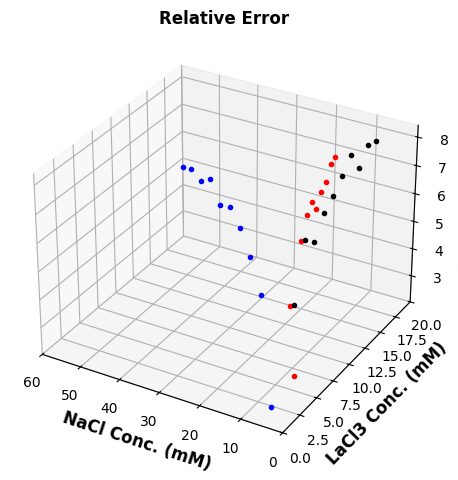

In [68]:
# residuals percent or fraction
residuals_percent3 = [100*e3[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32 = [100*e32[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33 = [100*e33[i]/cond_exp33[i] for i in range(ndata4)]

# absolute value of relative error
residuals_percent3_abs = [np.abs(residuals_percent3[i]) for i in range(ndata4)]
residuals_percent32_abs = [np.abs(residuals_percent32[i]) for i in range(ndata4)]
residuals_percent33_abs = [np.abs(residuals_percent33[i]) for i in range(ndata4)]
print(np.mean(residuals_percent3_abs))
print(np.mean(residuals_percent32_abs))
print(np.mean(residuals_percent33_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, residuals_percent3, "r.")
ax.plot3D(NaCl_conc22, LaCl3_conc22, residuals_percent32, "b.")
ax.plot3D(NaCl_conc23, LaCl3_conc23, residuals_percent33, ".", color="black")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaCl3 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("proportion_msc_model_na_la.png")
plt.show()

# Single Salts (NaCl)

## Data for NaCl

In [69]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl_cleaned.csv")
conc_nacl = specific_data["NaCl conc"]
cond_exp_nacl = specific_data["NaCl cond cal"]

# number of data points
ndata_nacl = len(cond_exp_nacl)

## NaCl Predictions

In [70]:
# constants
diffusion_coeff_4 = [Diff_Na, Diff_Cl] # diffusion coefficients of Na, and Cl, respectively
valency_4 = [z_Na, z_Cl] # valencies of Na, and Cl, respectively
diameter_4 = [sigma_Na, sigma_Cl] # effective ionic diameters of Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con4 = cd.msa_transport(valency_4, diameter_4, diffusion_coeff_4, T, voltage, distance, eta, epsilon, conc_nacl)

Relaxation correction: [-1.27244532e-11 -1.27244532e-11]
Hydrodynamic correction: [-0.15923593 -0.10465711]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


In [71]:
# constants
sigma_Na_reg = 100*10**(-12)
diameter_4_reg = [sigma_Na_reg, sigma_Cl] # effective ionic diameters of Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con4_reg = cd.msa_transport(valency_4, diameter_4_reg, diffusion_coeff_4, T, voltage, distance, eta, epsilon, conc_nacl)

Relaxation correction: [-9.78980843e-12 -9.78980843e-12]
Hydrodynamic correction: [-0.1694418  -0.10748711]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


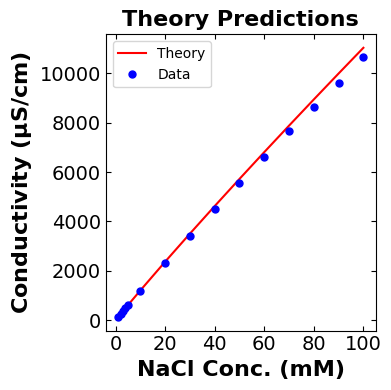

In [72]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, all_cond_calc_con4, "r-", label="Theory")
plt.plot(conc_nacl, cond_exp_nacl, "b.", markersize=10, label="Data")
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.legend()
plt.tight_layout()
# plt.savefig("msc_model_na.png")
plt.show()

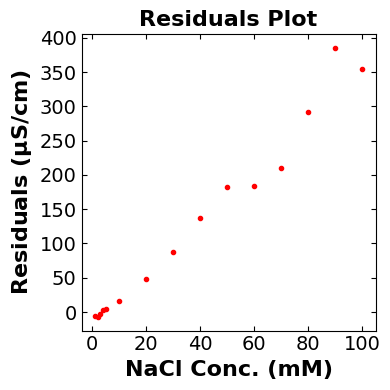

In [73]:
# residuals
e_nacl = [all_cond_calc_con4[i] - cond_exp_nacl[i] for i in range(ndata_nacl)]
e_nacl_reg = [all_cond_calc_con4_reg[i] - cond_exp_nacl[i] for i in range(ndata_nacl)]

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, e_nacl, "r.")
plt.title("Residuals Plot", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.tight_layout()
# plt.savefig("residuals_msc_model_na.png")
plt.show()

2.5159148558609856


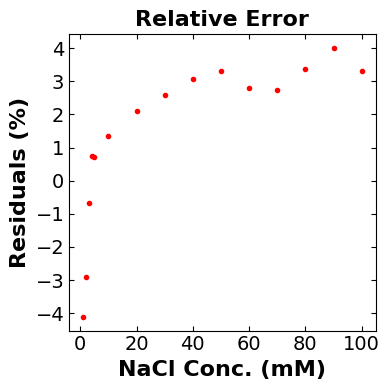

In [74]:
# residuals percent or fraction
residuals_percent_nacl = [100*e_nacl[i]/cond_exp_nacl[i] for i in range(ndata_nacl)]

# absolute value of relative error
residuals_percent_nacl_abs = [np.abs(residuals_percent_nacl[i]) for i in range(ndata_nacl)]
print(np.mean(residuals_percent_nacl_abs))

# visualizing in plot
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, residuals_percent_nacl, "r.")
plt.title("Relative Error", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.tight_layout()
# plt.savefig("proportion_msc_model_na.png")
plt.show()

## Variant Shedlovsky Model

### Constants

In [75]:
# solvent viscosity in poise
eta_shed = 8.903*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance from an ion within which no other ion can penetrate in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)

### NaCl

In [76]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl.csv")
molar_conc_specific_Na = specific_data["NaCl conc"]
specific_cond_exp_Na = specific_data["NaCl cond"]
specific_cond_calibrated_Na = specific_data["NaCl cond cal"]

# number of data points
ndata3 = len(specific_cond_exp_Na)

In [77]:
# concentration in M
conc2 = [molar_conc_specific_Na[i]*10**(-3) for i in range(ndata3)]

# specific conductivity in micro Siemen per cm
specific_cond_calc_Na = cd.variant_shedlovsky(conc2, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

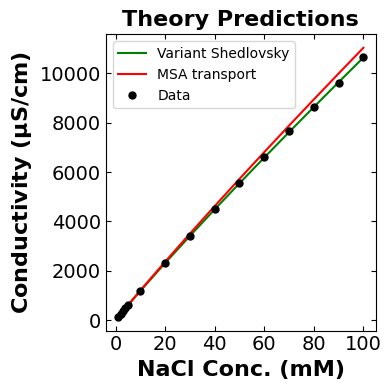

In [78]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_Na, specific_cond_calc_Na, color="green", label="Variant Shedlovsky")
plt.plot(conc_nacl, all_cond_calc_con4, "r-", label="MSA transport")
# plt.plot(conc_nacl, all_cond_calc_con4_reg, "b-", label="MSA transport regressed")
plt.plot(molar_conc_specific_Na, specific_cond_calibrated_Na, ".", color="black", markersize=10, label="Data")
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.tight_layout()
# plt.savefig("msc_single_model_comparison.png")
# plt.savefig("msc_single_model_comparison2.png")
plt.show()

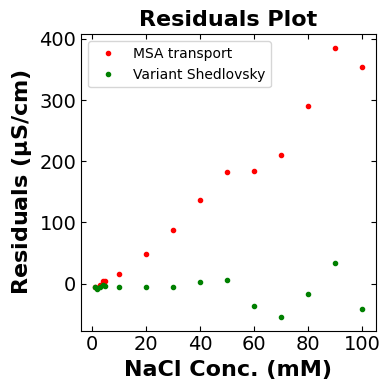

In [79]:
# residuals
residuals_Na = [specific_cond_calc_Na[i] - specific_cond_calibrated_Na[i] for i in range(ndata3)]

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, e_nacl, "r.", label="MSA transport")
# plt.plot(conc_nacl, e_nacl_reg, "b.", label="MSA transport regressed")
plt.plot(molar_conc_specific_Na, residuals_Na, ".", color="green", label="Variant Shedlovsky")
plt.title("Residuals Plot", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.tight_layout()
# plt.savefig("residuals_msc_single_comparison.png")
# plt.savefig("residuals_msc_single_comparison2.png")
plt.show()

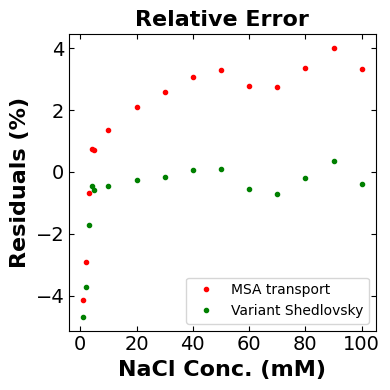

In [80]:
# residuals percent or fraction
residuals_percent_Na = [100*residuals_Na[i]/specific_cond_calibrated_Na[i] for i in range(ndata3)]

# visualizing in plot
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, residuals_percent_nacl, "r.", label="MSA transport")
plt.plot(molar_conc_specific_Na, residuals_percent_Na, ".", color="green", label="Variant Shedlovsky")
plt.title("Relative Error", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.tight_layout()
# plt.savefig("proportion_msc_single_comparison.png")
plt.show()

### CaCl2

In [81]:
# loading CaCl2 specific conductivity data
specific_data = pd.read_csv("./Data/CaCl2.csv")
molar_conc_specific_Ca_fig = specific_data["CaCl2_conc"]
specific_cond_calibrated_Ca_fig = specific_data["CaCl2_cond_cal"]

# number of data points
ndata_Ca_fig = len(specific_cond_calibrated_Ca_fig)

In [82]:
# diffusion coefficients, valencies, and hard sphere diameters of the two salts system
diffusion_coeff_4 = [Diff_Ca, Diff_Cl]
valency_4 = [z_Ca, z_Cl]
diameter_4 = [sigma_Ca, sigma_Cl]

# calculate the bulk conductivity using the MSA transport model
msa_cond_CaCl2 = cd.msa_transport(valency_4, diameter_4, diffusion_coeff_4, T, voltage, distance, eta, epsilon, molar_conc_specific_Ca_fig)

# evaluate the salts concentration in M using the cation ratio
conc_CaCl2_shed = [molar_conc_specific_Ca_fig[i]*10**(-3) for i in range(ndata_Ca_fig)]

# calculate the bulk conductivity using the variant Shedlovsky model
variant_shed_cond_CaCl2 = cd.variant_shedlovsky(conc_CaCl2_shed, T, epsilon, eta_shed, lambda_0_CaCl2, a_CaCl2, z_Ca, z_Cl, 
                             lambda_0_Ca, lambda_0_Cl)

Relaxation correction: [-3.56524937e-11 -3.56524937e-11]
Hydrodynamic correction: [-0.41781655 -0.16284976]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.66666667 0.33333333]
Transport number: [0.4380531 0.5619469]
Omega: [1.92351992e+11 4.93509152e+11]
ksi: [[ 1.38221033 -0.61018268]
 [ 0.53873552  1.22036535]]


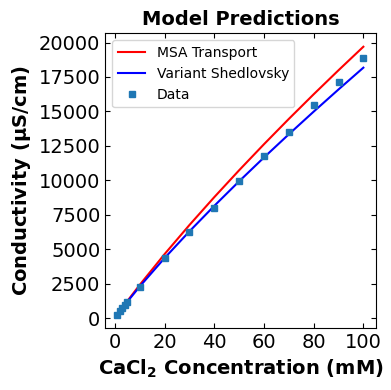

In [83]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_Ca_fig, msa_cond_CaCl2, "r-", label="MSA Transport")
plt.plot(molar_conc_specific_Ca_fig, variant_shed_cond_CaCl2, "b-", label="Variant Shedlovsky")
plt.plot(molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, "s", markersize=5, label="Data")
plt.xlabel("CaC$\mathbf{l_2}$ Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Model Predictions", fontsize=14,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("msa_var_shed_cacl2.png")
plt.show()

### LaCl3

In [84]:
# loading LaCl3 specific conductivity data
specific_data = pd.read_csv("./Data/LaCl3.csv")
molar_conc_specific_La_fig = specific_data["LaCl3 conc"]
specific_cond_calibrated_La_fig = specific_data["LaCl3 cond cal"]

# number of data points
ndata_La_fig = len(specific_cond_calibrated_La_fig)

In [85]:
# diffusion coefficients, valencies, and hard sphere diameters of the two salts system
diffusion_coeff_3 = [Diff_La, Diff_Cl]
valency_3 = [z_La, z_Cl]
diameter_3 = [sigma_La, sigma_Cl]

# calculate the bulk conductivity using the MSA transport model
msa_cond_LaCl3 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, voltage, distance, eta, epsilon, molar_conc_specific_La_fig)

# evaluate the salts concentration in M using the cation ratio
conc_LaCl3_shed = [molar_conc_specific_La_fig[i]*10**(-3) for i in range(ndata_La_fig)]

# calculate the bulk conductivity using the variant Shedlovsky model
variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, T, epsilon, eta_shed, lambda_0_LaCl3, a_LaCl3, z_La, z_Cl, 
                             lambda_0_La, lambda_0_Cl)

Relaxation correction: [-4.86870775e-11 -4.86870775e-11]
Hydrodynamic correction: [-0.53106778 -0.16238354]
omega_bar: 236129071587.12134
Alpha: [0.0, 357917325038.36115]
Mew: [0.75 0.25]
Transport number: [0.47750064 0.52249936]
Omega: [1.50335711e+11 4.93509152e+11]
ksi: [[ 1.37883561 -0.43937499]
 [ 0.42002915  1.31812498]]


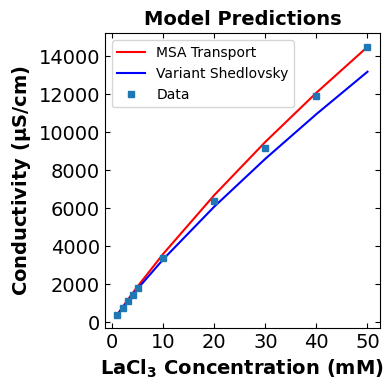

In [86]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_La_fig, msa_cond_LaCl3, "r-", label="MSA Transport")
plt.plot(molar_conc_specific_La_fig, variant_shed_cond_LaCl3, "b-", label="Variant Shedlovsky")
plt.plot(molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, "s", markersize=5, label="Data")
plt.xlabel("LaC$\mathbf{l_3}$ Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Model Predictions", fontsize=14,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("msa_var_shed_lacl3.png")
plt.show()

## NaCl and CaCl2 Model Comparison

### NaCl

In [87]:
# constants
temp_NaCl_CaCl2 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_NaCl_CaCl2 = (a_NaCl + a_CaCl2)/2

# concentration in M
conc = [NaCl_conc[i]*10**(-3) for i in range(ndata)]
conc12 = [NaCl_conc12[i]*10**(-3) for i in range(ndata)]
conc13 = [NaCl_conc13[i]*10**(-3) for i in range(ndata)]

# specific conductivity in micro Siemen per cm
specific_cond_nacl = cd.variant_shedlovsky(conc, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_12 = cd.variant_shedlovsky(conc12, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_13 = cd.variant_shedlovsky(conc13, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

### CaCl2

In [88]:
# concentration in M
conc_cacl2 = [CaCl2_conc[i]*10**(-3) for i in range(ndata)]
conc_cacl2_12 = [CaCl2_conc12[i]*10**(-3) for i in range(ndata)]
conc_cacl2_13 = [CaCl2_conc13[i]*10**(-3) for i in range(ndata)]

# specific conductivity in micro Siemen per cm
specific_cond_cacl2 = cd.variant_shedlovsky(conc_cacl2, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                             lambda_0_Cl)
specific_cond_cacl2_12 = cd.variant_shedlovsky(conc_cacl2_12, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                                lambda_0_Cl)
specific_cond_cacl2_13 = cd.variant_shedlovsky(conc_cacl2_13, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                                lambda_0_Cl)

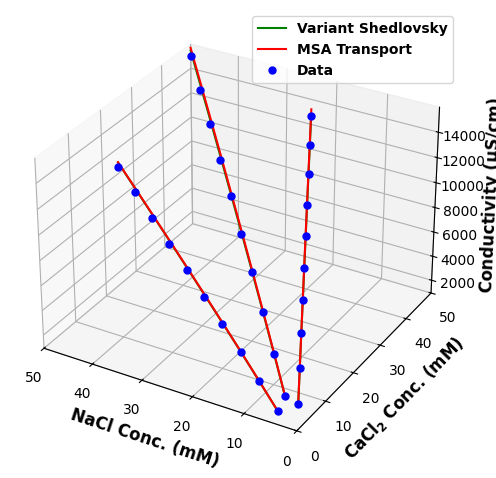

In [89]:
# bulk conductivity
specific_cond = [specific_cond_nacl[i] + specific_cond_cacl2[i] for i in range(ndata)]
specific_cond_12 = [specific_cond_nacl_12[i] + specific_cond_cacl2_12[i] for i in range(ndata)]
specific_cond_13 = [specific_cond_nacl_13[i] + specific_cond_cacl2_13[i] for i in range(ndata)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, specific_cond, color="green", label="Variant Shedlovsky")
ax.plot3D(NaCl_conc12, CaCl2_conc12, specific_cond_12, color="green")
ax.plot3D(NaCl_conc13, CaCl2_conc13, specific_cond_13, color="green")
ax.plot3D(NaCl_conc, CaCl2_conc, all_cond_calc_con, color="red", label="MSA Transport")
ax.plot3D(NaCl_conc12, CaCl2_conc12, all_cond_calc_con12, color="red")
ax.plot3D(NaCl_conc13, CaCl2_conc13, all_cond_calc_con13, color="red")
ax.plot3D(NaCl_conc, CaCl2_conc, cond_exp, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc12, CaCl2_conc12, cond_exp12, "b.", markersize=10)
ax.plot3D(NaCl_conc13, CaCl2_conc13, cond_exp13, "b.", markersize=10)
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("msc_single_na_ca_comparison.png")
plt.show()

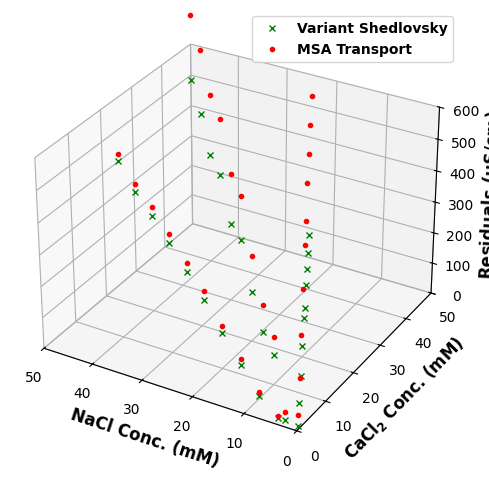

In [90]:
# residuals for NaCl and CaCl2
e_2 = [specific_cond[i] - cond_exp[i] for i in range(ndata)]
e12_2 = [specific_cond_12[i] - cond_exp12[i] for i in range(ndata)]
e13_2 = [specific_cond_13[i] - cond_exp13[i] for i in range(ndata)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, e_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc12, CaCl2_conc12, e12_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc13, CaCl2_conc13, e13_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc, CaCl2_conc, e, ".", color="red", label="MSA Transport")
ax.plot3D(NaCl_conc12, CaCl2_conc12, e12, ".", color="red")
ax.plot3D(NaCl_conc13, CaCl2_conc13, e13, ".", color="red")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.set_zlim(0, 600)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("residuals_msc_single_na_ca_comparison.png")
plt.show()

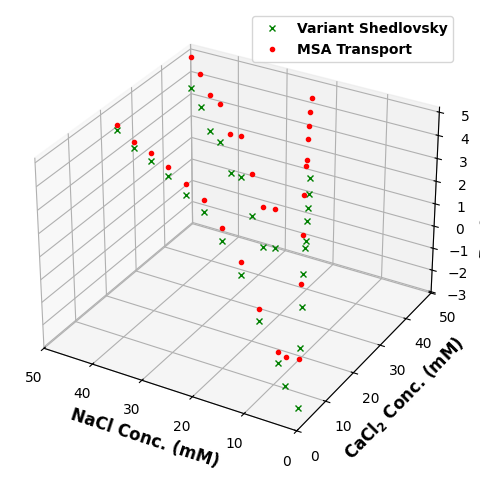

In [91]:
# residuals fraction
residuals_percent_2 = [100*e_2[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12_2 = [100*e12_2[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13_2 = [100*e13_2[i]/cond_exp13[i] for i in range(ndata)]

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, residuals_percent_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc12, CaCl2_conc12, residuals_percent12_2, "x", color="green", markersize=5)
ax.plot3D(NaCl_conc13, CaCl2_conc13, residuals_percent13_2, "x", color="green", markersize=5)
ax.plot3D(NaCl_conc, CaCl2_conc, residuals_percent, "r.", label="MSA Transport")
ax.plot3D(NaCl_conc12, CaCl2_conc12, residuals_percent12, "r.")
ax.plot3D(NaCl_conc13, CaCl2_conc13, residuals_percent13, "r.")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("proportion_msc_single_na_ca_comparison.png")
plt.show()

## NaCl and LaCl3 Model Comparison

### NaCl

In [92]:
# constants
temp_NaCl_LaCl3 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_NaCl_LaCl3 = (a_NaCl + a_LaCl3)/2

# concentration in M
conc_nacl_21 = [NaCl_conc2[i]*10**(-3) for i in range(ndata4)]
conc_nacl_22 = [NaCl_conc22[i]*10**(-3) for i in range(ndata4)]
conc_nacl_23 = [NaCl_conc23[i]*10**(-3) for i in range(ndata4)]

# specific conductivity in micro Siemen per cm
specific_cond_nacl_21 = cd.variant_shedlovsky(conc_nacl_21, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)
specific_cond_nacl_22 = cd.variant_shedlovsky(conc_nacl_22, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)
specific_cond_nacl_23 = cd.variant_shedlovsky(conc_nacl_23, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)

### LaCl3

In [93]:
# concentration in M
conc_lacl3_11 = [LaCl3_conc2[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_12 = [LaCl3_conc22[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_13 = [LaCl3_conc23[i]*10**(-3) for i in range(ndata4)]

# specific conductivity in micro Siemen per cm
specific_cond_lacl3_11 = cd.variant_shedlovsky(conc_lacl3_11, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)
specific_cond_lacl3_12 = cd.variant_shedlovsky(conc_lacl3_12, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)
specific_cond_lacl3_13 = cd.variant_shedlovsky(conc_lacl3_13, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)

### NaCl & LaCl3

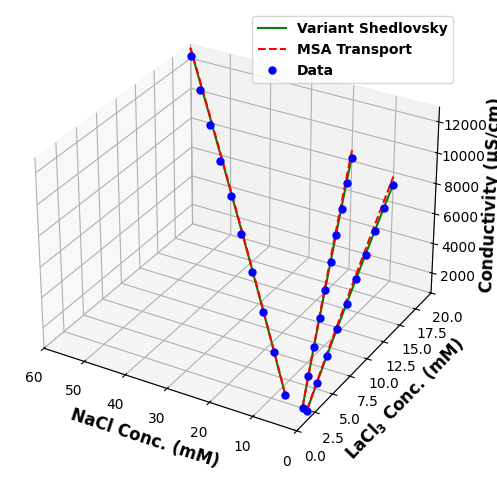

In [94]:
# bulk conductivity
specific_cond_21 = [specific_cond_nacl_21[i] + specific_cond_lacl3_11[i] for i in range(ndata4)]
specific_cond_22 = [specific_cond_nacl_22[i] + specific_cond_lacl3_12[i] for i in range(ndata4)]
specific_cond_23 = [specific_cond_nacl_23[i] + specific_cond_lacl3_13[i] for i in range(ndata4)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, specific_cond_21, color="green", label="Variant Shedlovsky")
ax.plot3D(NaCl_conc22, LaCl3_conc22, specific_cond_22, color="green")
ax.plot3D(NaCl_conc23, LaCl3_conc23, specific_cond_23, color="green")
ax.plot3D(NaCl_conc2, LaCl3_conc2, all_cond_calc_con3, "--", color="red", label="MSA Transport")
ax.plot3D(NaCl_conc22, LaCl3_conc22, all_cond_calc_con32, "--", color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, all_cond_calc_con33, "--", color="red")
ax.plot3D(NaCl_conc2, LaCl3_conc2, cond_exp3, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc22, LaCl3_conc22, cond_exp32, "b.", markersize=10)
ax.plot3D(NaCl_conc23, LaCl3_conc23, cond_exp33, "b.", markersize=10)
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("msc_single_na_la_comparison.png")
plt.show()

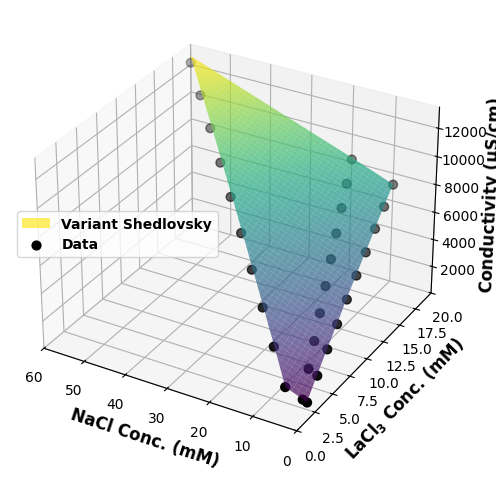

In [95]:
# Combine all data
NaCl_all = np.concatenate([NaCl_conc2, NaCl_conc22, NaCl_conc23])
LaCl_all = np.concatenate([LaCl3_conc2, LaCl3_conc22, LaCl3_conc23])
cond_exp_all = np.concatenate([cond_exp3, cond_exp32, cond_exp33])
specific_cond_all_shed = np.concatenate([specific_cond_21, specific_cond_22, specific_cond_23])
specific_cond_all_msa = np.concatenate([all_cond_calc_con3, all_cond_calc_con32, all_cond_calc_con33])

# Create grid to interpolate over
NaCl_range = np.linspace(NaCl_all.min(), NaCl_all.max(), 1000)
LaCl_range = np.linspace(LaCl_all.min(), LaCl_all.max(), 1000)
NaCl_grid, LaCl_grid = np.meshgrid(NaCl_range, LaCl_range)

# Interpolate surface for calculated conductivity
specific_cond_grid_shed = griddata(
    (NaCl_all, LaCl_all),
    specific_cond_all_shed,
    (NaCl_grid, LaCl_grid),
    method='cubic'
)

specific_cond_grid_msa = griddata(
    (NaCl_all, LaCl_all),
    specific_cond_all_msa,
    (NaCl_grid, LaCl_grid),
    method='cubic'
)

# setup the plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plot the model prediction surface
surf_shed = ax.plot_surface(NaCl_grid, LaCl_grid, specific_cond_grid_shed, cmap=cm.viridis, 
                            linewidth=0.3, alpha=0.7, label="Variant Shedlovsky")

# surf_msa = ax.plot_surface(NaCl_grid, LaCl_grid, specific_cond_grid_msa, cmap=cm.coolwarm, 
#                            linewidth=0.3, alpha=0.4, label="MSA Transport")

# plot data
ax.scatter(NaCl_all, LaCl_all, cond_exp_all, color='black', s=40, label="Data", edgecolors="black", zorder=20)

# add plot labels and limits
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"}, loc="center left")
plt.tight_layout()
plt.savefig("msc_single_na_la_comparison_plane.png")
plt.show()

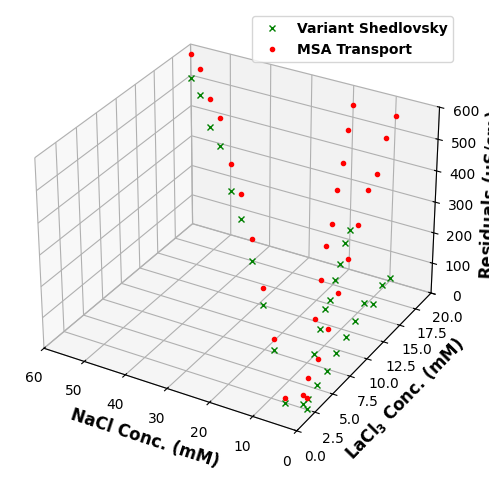

In [96]:
# residuals for NaCl and LaCl3
e3_2 = [specific_cond_21[i] - cond_exp3[i] for i in range(ndata4)]
e32_2 = [specific_cond_22[i] - cond_exp32[i] for i in range(ndata4)]
e33_2 = [specific_cond_23[i] - cond_exp33[i] for i in range(ndata4)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, e3_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc22, LaCl3_conc22, e32_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc23, LaCl3_conc23, e33_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc2, LaCl3_conc2, e3, ".", color="red", label="MSA Transport")
ax.plot3D(NaCl_conc22, LaCl3_conc22, e32, ".", color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, e33, ".", color="red")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.set_zlim(0, 600)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("residuals_msc_single_na_la_comparison.png")
plt.show()

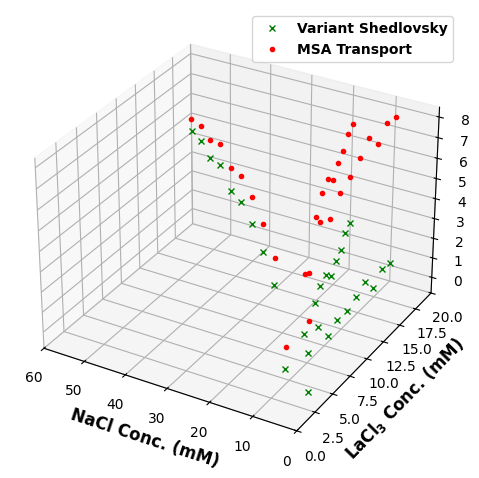

In [97]:
# residuals fraction
residuals_percent3_2 = [100*e3_2[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32_2 = [100*e32_2[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33_2 = [100*e33_2[i]/cond_exp33[i] for i in range(ndata4)]

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, residuals_percent3_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc22, LaCl3_conc22, residuals_percent32_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc23, LaCl3_conc23, residuals_percent33_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc2, LaCl3_conc2, residuals_percent3, ".", color="red", label="MSA Transport")
ax.plot3D(NaCl_conc22, LaCl3_conc22, residuals_percent32, ".", color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, residuals_percent33, ".", color="red")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("proportion_msc_single_na_la_comparison.png")
plt.show()

## CaCl2 and LaCl3 Model Comparison

### CaCl2

In [98]:
# constants
temp_CaCl2_LaCl3 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_CaCl2_LaCl3 = (a_CaCl2 + a_LaCl3)/2

# concentration in M
conc_cacl2_21 = [CaCl2_conc2[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_22 = [CaCl2_conc22[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_23 = [CaCl2_conc23[i]*10**(-3) for i in range(ndata2)]

# specific conductivity in micro Siemen per cm
specific_cond_cacl2_21 = cd.variant_shedlovsky(conc_cacl2_21, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)
specific_cond_cacl2_22 = cd.variant_shedlovsky(conc_cacl2_22, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)
specific_cond_cacl2_23 = cd.variant_shedlovsky(conc_cacl2_23, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)

### LaCl3

In [99]:
# concentration in M
conc_lacl3_21 = [LaCl3_conc[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_22 = [LaCl3_conc12[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_23 = [LaCl3_conc13[i]*10**(-3) for i in range(ndata2)]

# specific conductivity in micro Siemen per cm
specific_cond_lacl3_21 = cd.variant_shedlovsky(conc_lacl3_21, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)
specific_cond_lacl3_22 = cd.variant_shedlovsky(conc_lacl3_22, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)
specific_cond_lacl3_23 = cd.variant_shedlovsky(conc_lacl3_23, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)

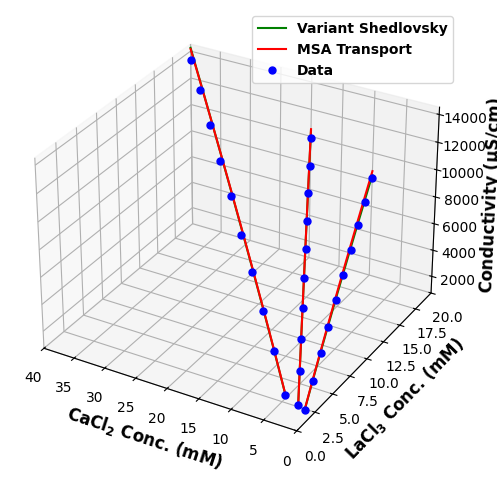

In [100]:
# bulk conductivity
specific_cond_31 = [specific_cond_cacl2_21[i] + specific_cond_lacl3_21[i] for i in range(ndata2)]
specific_cond_32 = [specific_cond_cacl2_22[i] + specific_cond_lacl3_22[i] for i in range(ndata2)]
specific_cond_33 = [specific_cond_cacl2_23[i] + specific_cond_lacl3_23[i] for i in range(ndata2)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, specific_cond_31, color="green", label="Variant Shedlovsky")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, specific_cond_32, color="green")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, specific_cond_33, color="green")
ax.plot3D(CaCl2_conc2, LaCl3_conc, all_cond_calc_con2, color="red", label="MSA Transport")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, all_cond_calc_con22, color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, all_cond_calc_con23, color="red")
ax.plot3D(CaCl2_conc2, LaCl3_conc, cond_exp2, "b.", markersize=10, label="Data")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, cond_exp22, "b.", markersize=10)
ax.plot3D(CaCl2_conc23, LaCl3_conc13, cond_exp23, "b.", markersize=10)
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("msc_single_ca_la_comparison.png")
plt.show()

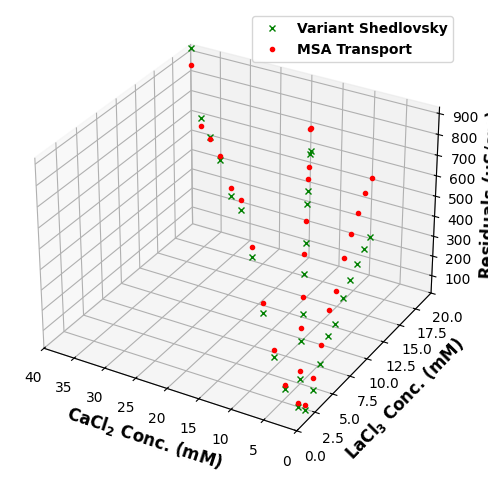

In [101]:
# residuals for CaCl2 and LaCl3
e2_2 = [specific_cond_31[i] - cond_exp2[i] for i in range(ndata2)]
e22_2 = [specific_cond_32[i] - cond_exp22[i] for i in range(ndata2)]
e23_2 = [specific_cond_33[i] - cond_exp23[i] for i in range(ndata2)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, e2_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, e22_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, e23_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc2, LaCl3_conc, e2, ".", color="red", label="MSA Transport")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, e22, ".", color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, e23, ".", color="red")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("residuals_msc_single_ca_la_comparison.png")
plt.show()

5.56479669302488
6.213878603615317
3.208647694457556


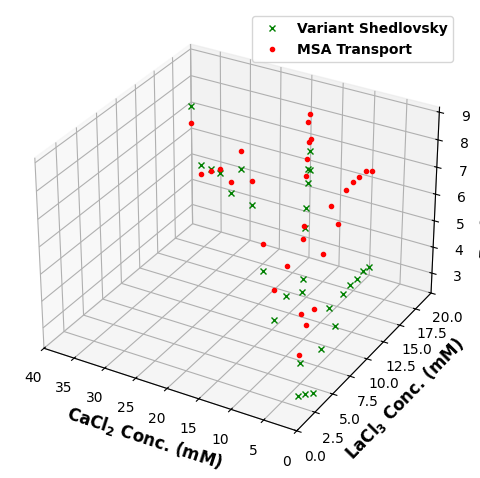

In [102]:
# residuals fraction
residuals_percent2_2 = [100*e2_2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22_2 = [100*e22_2[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23_2 = [100*e23_2[i]/cond_exp23[i] for i in range(ndata2)]

# absolute value of relative error
residuals_percent2_2_abs = [np.abs(residuals_percent2_2[i]) for i in range(ndata2)]
residuals_percent22_2_abs = [np.abs(residuals_percent22_2[i]) for i in range(ndata2)]
residuals_percent23_2_abs = [np.abs(residuals_percent23_2[i]) for i in range(ndata2)]
print(np.mean(residuals_percent2_2_abs))
print(np.mean(residuals_percent22_2_abs))
print(np.mean(residuals_percent23_2_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, residuals_percent2_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, residuals_percent22_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, residuals_percent23_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc2, LaCl3_conc, residuals_percent2, ".", color="red", label="MSA Transport")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, residuals_percent22, ".", color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, residuals_percent23, ".", color="red")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("proportion_msc_single_ca_la_comparison.png")
plt.show()